# Poisoning Budget Analysis (Intermediate)

This notebook studies **how the proportion of poisoned training data** affects classifier performance under a **white-box, training-time label-flipping** attack on two text-based tasks:

1. **Binary classification** — Enron spam detection  
2. **Multi-class classification** — MURLs malware domain classification

---

## Theoretical framework

### Attack model: random label-flipping

The attacker does **not** modify features $(X)$. They only corrupt a subset of training labels $(y)$ in the pristine training set. This is a classic **availability / reliability** poisoning pattern: the model is trained on misleading supervision while inputs remain realistic.

### Cost budget \(C\)

$(C \in [0, 1])$ is the **maximum fraction of training points** the attacker may relabel. For example, $(C = 0.10)$ means at most 10% of training labels are flipped. Larger $(C)$ means a more expensive attack (more annotations corrupted).

### Attacker goal: reliability attack

The objective is to **maximize prediction error on clean test data** — i.e., degrade generalization on held-out, unmodified examples. I therefore keep the **test set completely clean** and only poison **training** labels.



## Step 1: Setup and data loading


In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Reproducibility
RANDOM_STATE = 40
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
ENRON_CSV = DATA_DIR / "enron_spam.csv"
MURLs_CSV = DATA_DIR / "malicious_phish.csv"

POISONING_BUDGETS = [0.0, 0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45] #, 0.50, 0.55, 0.60, 0.65, 0.70]
TARGETED_BUDGETS = [0.0, 0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
MAX_TFIDF_FEATURES = 5000
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
import os
import zipfile
import pandas as pd
from pathlib import Path
import kaggle

ENRON_KAGGLE_DATASET  = "marcelwiechmann/enron-spam-data"
MURLs_KAGGLE_DATASET = "sid321axn/malicious-urls-dataset"     
ENRON_CSV_NAME  = "enron_spam_data.csv"   
MURLs_CSV_NAME = "malicious_phish.csv"    

DATA_DIR = Path("data")


def _download_kaggle_dataset(dataset_slug: str, dest_dir: Path) -> None:
    dest_dir.mkdir(parents=True, exist_ok=True)
    print(f"[Kaggle] Downloading '{dataset_slug}' → {dest_dir}")
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(dataset_slug, path=str(dest_dir), unzip=True, quiet=False)

def _ensure_csv(dataset_slug: str, csv_name: str, dest_dir: Path) -> Path:
    """Return the path to *csv_name*, downloading the dataset first if needed."""
    csv_path = dest_dir / csv_name
    if not csv_path.exists():
        _download_kaggle_dataset(dataset_slug, dest_dir)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Expected '{csv_name}' inside dataset '{dataset_slug}', "
            f"but it was not found in {dest_dir}. "
            "Check the filename constant at the top of this file."
        )
    return csv_path


def _load_csv(csv_path: Path, dataset_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # ── Enron: combine Subject + Message into a single text field ────
    if "Subject" in df.columns and "Message" in df.columns:
        df["text"] = df["Subject"].fillna("") + " " + df["Message"].fillna("")
        df["label"] = df["Spam/Ham"]

    # ── Malicious URLs dataset ─────
    if "url" in df.columns:
        df = df.rename(columns={"url": "text", "type": "label"})

    required = {"text", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"{dataset_name} CSV is missing columns {missing}. "
            f"Actual columns: {df.columns.tolist()}"
        )

    return df[["text", "label"]].dropna().reset_index(drop=True)

# ── Public loaders ───

def load_enron_dataset(
    csv_name: str = ENRON_CSV_NAME,
    dataset_slug: str = ENRON_KAGGLE_DATASET,
    dest_dir: Path = DATA_DIR / "enron",
) -> pd.DataFrame:
    """Download (if necessary) and load the Enron spam dataset from Kaggle."""
    csv_path = _ensure_csv(dataset_slug, csv_name, dest_dir)
    return _load_csv(csv_path, "Enron")


def load_murls_dataset(
    csv_name: str = MURLs_CSV_NAME,
    dataset_slug: str = MURLs_KAGGLE_DATASET,
    dest_dir: Path = DATA_DIR / "murls",
) -> pd.DataFrame:
    """Download (if necessary) and load the Malicious URLs dataset from Kaggle."""
    csv_path = _ensure_csv(dataset_slug, csv_name, dest_dir)
    return _load_csv(csv_path, "MURLs")

In [3]:
df_enron = load_enron_dataset()
df_murls = load_murls_dataset()

print("Enron shape:", df_enron.shape)
print("MURLs shape:", df_murls.shape)
print(df_murls.head())

Enron shape: (33716, 2)
MURLs shape: (651191, 2)
                                                text       label
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement


In [4]:
import os
print(os.listdir("data/enron"))
print(os.listdir("data/MURLs"))

['build_data_file.py', 'enron_spam_data.csv', 'LICENSE', 'README.md']
['malicious_phish.csv']


## Step 2: Preprocessing and feature extraction

Text is converted with **TF–IDF** (`max_features=5000` for speed). I use an **80/20 train–test split**. The **test labels and features are never poisoned** — they are the ground truth for measuring attacker utility (degradation on clean data).

In [5]:
def preprocess_and_vectorize(
    df: pd.DataFrame,
    max_features: int = MAX_TFIDF_FEATURES,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
):
    #TF-IDF features, label encoding, and stratified train/test split.
    texts = df["text"].astype(str)
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df["label"])
    num_classes = len(label_encoder.classes_)

    vectorizer = TfidfVectorizer(max_features=max_features)
    X = vectorizer.fit_transform(texts)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    return X_train, X_test, y_train, y_test, num_classes, label_encoder

## Step 3: Poisoning logic

### Step 3.1: Poisoning logic (random label flipping)

Given budget $(C)$, I uniformly sample $(\lfloor C \cdot n \rfloor)$ training indices (at least one when $(C > 0)$ and $(n \geq 1))$ and flip their labels:

- **Binary:** $(0 \leftrightarrow 1)$  
- **Multi-class:** replace with a **uniformly random incorrect** class

Features $(X_{\text{train}})$ are unchanged — only $(y_{\text{train}})$ is corrupted, respecting the budget constraint.

In [6]:
def apply_label_flipping(
    y_train: np.ndarray,
    budget: float,
    num_classes: int,
    random_state: int = RANDOM_STATE, 
) -> np.ndarray:
    y_poisoned = np.array(y_train, copy=True)
    n = len(y_poisoned)
    if budget <= 0 or n == 0:
        return y_poisoned

    n_poison = int(np.floor(budget * n))
    if n_poison < 1:
        n_poison = 1
    n_poison = min(n_poison, n)

    rng = np.random.default_rng(random_state) #<----------- Randomness used here
    poison_indices = rng.choice(n, size=n_poison, replace=False)

    for idx in poison_indices:
        original = y_poisoned[idx]
        if num_classes == 2:
            y_poisoned[idx] = 1 - original
        else:
            candidates = [c for c in range(num_classes) if c != original]
            y_poisoned[idx] = rng.choice(candidates)

    return y_poisoned

### Step 3.2: Poisoning logic (targeted label flipping)


Unlike untargeted flipping which corrupts random labels, the targeted attack
simulates a **realistic adversary** who controls a subset of malicious training
samples and flips only their own class to benign:

- **Enron:** $\text{spam} \rightarrow \text{ham}$ — attacker hides their spam from the filter  
- **MURLs (primary):** $\text{malware} \rightarrow \text{benign}$ — attacker conceals malware URLs  
- **MURLs (secondary):** $\text{phishing} \rightarrow \text{benign}$ — attacker conceals phishing URLs  

Only samples of the **source class** are eligible for flipping, making the budget
constraint tighter — if the source class is rare, the effective poison rate is
capped by its frequency in the training set.

In [12]:
def apply_targeted_poison(
    y_train: np.ndarray,
    budget: float,
    source_class: int,
    target_class: int,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    y_poisoned = np.array(y_train, copy=True)
    n = len(y_poisoned)
    if budget <= 0 or n == 0:
        return y_poisoned

    n_budget = int(np.floor(budget * n))
    if n_budget < 1:
        n_budget = 1

    source_indices = np.where(y_train == source_class)[0]
    
    # ── Cap at 30% of source class to always preserve class balance ──────────
    max_flippable = int(len(source_indices) * 0.30)
    n_flip = min(n_budget, max_flippable)

    if n_flip == 0:
        return y_poisoned

    # ── Safety check: ensure at least 2 classes remain after flipping ────────
    n_source_remaining = len(source_indices) - n_flip
    if n_source_remaining == 0:
        return y_poisoned  # skip this budget silently

    rng = np.random.default_rng(random_state)
    flip_indices = rng.choice(source_indices, size=n_flip, replace=False)
    y_poisoned[flip_indices] = target_class

    return y_poisoned

## Step 4: Experimal Loop

### Step 4.1: Experimental loop untargeted

For each dataset and each budget $(C \in \{0, 1\%, 5\%, \ldots, 30\%\})$:

1. Flip labels on the training set only.  
2. Retrain **Logistic Regression** (fast linear baseline on sparse TF–IDF).  
3. Evaluate on the **clean test set**.  
4. Record Accuracy, Precision, Recall, and F1 (macro for multi-class).

Rising $(C)$ should monotonically stress the model under a reliability attack, manifesting as loIr attacker-facing utility (worse metrics for the defender).

In [13]:
def build_classifier(random_state: int = RANDOM_STATE) -> LogisticRegression:
    """Fast linear baseline for sparse TF-IDF features."""
    return LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=random_state,
    )


def evaluate_on_clean_test(
    y_test: np.ndarray,
    y_pred: np.ndarray,
    average: str,
) -> dict:
    """Compute standard metrics on unpoisoned test labels."""
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
    }


def run_poisoning_experiment(
    X_train,
    X_test,
    y_train: np.ndarray,
    y_test: np.ndarray,
    num_classes: int,
    dataset_name: str,
    budgets: list = None,
    metric_average: str = "binary",
) -> pd.DataFrame:
    """SIep poisoning budgets; return one row per (budget, metric)."""
    if budgets is None:
        budgets = POISONING_BUDGETS

    rows = []
    for budget in budgets:
        y_train_poisoned = apply_label_flipping(
            y_train, budget=budget, num_classes=num_classes
        )
        clf = build_classifier()
        clf.fit(X_train, y_train_poisoned)
        y_pred = clf.predict(X_test)
        scores = evaluate_on_clean_test(y_test, y_pred, average=metric_average)

        for metric_name, value in scores.items():
            rows.append(
                {
                    "dataset": dataset_name,
                    "attack": "untargeted",
                    "flip": "random",
                    "budget": budget,
                    "budget_pct": budget * 100,
                    "metric": metric_name,
                    "score": value,
                }
            )
    return pd.DataFrame(rows)

### Run: Enron (binary) and MURLs (multi-class)

In [14]:
enron_df = load_enron_dataset()
MURLs_df = load_murls_dataset()

print(f"Enron samples: {len(enron_df):,} | classes: {enron_df['label'].nunique()}")
print(f"MURLs samples: {len(MURLs_df):,} | classes: {MURLs_df['label'].nunique()}")

Enron samples: 33,716 | classes: 2
MURLs samples: 651,191 | classes: 4


In [15]:
X_train_e, X_test_e, y_train_e, y_test_e, n_classes_e, le_e = preprocess_and_vectorize(enron_df)
X_train_u, X_test_u, y_train_u, y_test_u, n_classes_u, le_u = preprocess_and_vectorize(MURLs_df)

results_enron = run_poisoning_experiment(
    X_train_e,
    X_test_e,
    y_train_e,
    y_test_e,
    num_classes=n_classes_e,
    dataset_name="Enron (Binary)",
    metric_average="binary",
)

results_MURLs = run_poisoning_experiment(
    X_train_u, 
    X_test_u,
    y_train_u,
    y_test_u,
    num_classes=n_classes_u,
    dataset_name="MURLs (Multi-Class)",
    metric_average="macro",
)

# Untargeted results — will be merged with targeted results in Cell 4.2
results_enron = run_poisoning_experiment(
    X_train_e, X_test_e, y_train_e, y_test_e,
    num_classes=n_classes_e,
    dataset_name="Enron (Binary)",
    metric_average="binary",
)
results_MURLs = run_poisoning_experiment(
    X_train_u, X_test_u, y_train_u, y_test_u,
    num_classes=n_classes_u,
    dataset_name="MURLs (Multi-Class)",
    metric_average="macro",
)

### Step 4.2: Experimental loop targeted 

Mirrors the untargeted loop but uses `run_targeted_poisoning_experiment()`.
Results are tagged with `attack="targeted"` and `flip="source→target"` so they
can be directly compared against the untargeted baseline in the same DataFrame.

In [16]:
def run_targeted_poisoning_experiment(
    X_train,
    X_test,
    y_train: np.ndarray,
    y_test: np.ndarray,
    source_label: str,
    target_label: str,
    le: LabelEncoder,
    num_classes: int,
    dataset_name: str,
    metric_average: str = "binary",
    budgets: list[float] = POISONING_BUDGETS,
) -> pd.DataFrame:
    source_class = le.transform([source_label])[0]
    target_class = le.transform([target_label])[0]

    records = []
    for budget in budgets:
        y_poisoned = apply_targeted_poison(
            y_train,
            budget,
            source_class=source_class,
            target_class=target_class,
            random_state=RANDOM_STATE,
        )

        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        clf.fit(X_train, y_poisoned)
        y_pred = clf.predict(X_test)

        flip_label = f"{source_label}→{target_label}"
        records += [
            {"dataset": dataset_name, "attack": "targeted", "flip": flip_label,
             "budget": budget, "budget_pct": budget * 100,
             "metric": "accuracy",  "score": accuracy_score(y_test, y_pred)},
            {"dataset": dataset_name, "attack": "targeted", "flip": flip_label,
             "budget": budget, "budget_pct": budget * 100,
             "metric": "precision", "score": precision_score(y_test, y_pred, average=metric_average, zero_division=0)},
            {"dataset": dataset_name, "attack": "targeted", "flip": flip_label,
             "budget": budget, "budget_pct": budget * 100,
             "metric": "recall",    "score": recall_score(y_test, y_pred, average=metric_average, zero_division=0)},
            {"dataset": dataset_name, "attack": "targeted", "flip": flip_label,
             "budget": budget, "budget_pct": budget * 100,
             "metric": "f1",        "score": f1_score(y_test, y_pred, average=metric_average, zero_division=0)},
        ]

    return pd.DataFrame(records)


# ── Run targeted experiments ─────

# Enron: flip spam -> ham
results_enron_targeted = run_targeted_poisoning_experiment(
    X_train_e, X_test_e, y_train_e, y_test_e,
    source_label="spam",
    target_label="ham",
    le=le_e,
    num_classes=n_classes_e,
    dataset_name="Enron (Binary)",
    metric_average="binary",
    budgets = TARGETED_BUDGETS
)

# MURLs: flip malware -> benign
results_murls_malware = run_targeted_poisoning_experiment(
    X_train_u, X_test_u, y_train_u, y_test_u,
    source_label="malware",
    target_label="benign",
    le=le_u,
    num_classes=n_classes_u,
    dataset_name="MURLs (Multi-Class)",
    metric_average="macro",
    budgets = TARGETED_BUDGETS
)

# MURLs: flip phishing -> benign
results_murls_phishing = run_targeted_poisoning_experiment(
    X_train_u, X_test_u, y_train_u, y_test_u,
    source_label="phishing",
    target_label="benign",
    le=le_u,
    num_classes=n_classes_u,
    dataset_name="MURLs (Multi-Class)",
    metric_average="macro",
    budgets = TARGETED_BUDGETS
)

results_all = pd.concat([
    results_enron.assign(attack="untargeted", flip="random"),
    results_MURLs.assign(attack="untargeted", flip="random"),
    results_enron_targeted,
    results_murls_malware,
    results_murls_phishing,
], ignore_index=True)

results_all

,dataset,attack,flip,budget,budget_pct,metric,score
0,Enron (Binary),untargeted,random,0.00,0.0,accuracy,0.999407
1,Enron (Binary),untargeted,random,0.00,0.0,precision,0.998837
2,Enron (Binary),untargeted,random,0.00,0.0,recall,1.000000
3,Enron (Binary),untargeted,random,0.00,0.0,f1,0.999418
4,Enron (Binary),untargeted,random,0.01,1.0,accuracy,0.999407
...,...,...,...,...,...,...,...
207,MURLs (Multi-Class),targeted,phishing→benign,0.60,60.0,f1,0.866780
208,MURLs (Multi-Class),targeted,phishing→benign,0.70,70.0,accuracy,0.909789
209,MURLs (Multi-Class),targeted,phishing→benign,0.70,70.0,precision,0.937357
210,MURLs (Multi-Class),targeted,phishing→benign,0.70,70.0,recall,0.837926


## Step 5: Evaluation and visualization

Pivot tables summarize attacker utility: as **Poisoning Budget (%)** grows, metric scores on the **clean test set** should fall, indicating a successful reliability attack within budget $(C)$.

In [ ]:

def results_to_wide(df: pd.DataFrame) -> pd.DataFrame:
    """Wide table: one row per (attack, flip, budget), columns per metric."""
    wide = df.pivot_table(
        index=["dataset", "attack", "flip", "budget_pct"],
        columns="metric",
        values="score",
    ).reset_index()
    wide.columns.name = None
    return wide.sort_values(["attack", "flip", "budget_pct"])

print("=== Enron (Binary) — Untargeted ===")
display(results_to_wide(results_all[
    (results_all["dataset"] == "Enron (Binary)") &
    (results_all["attack"] == "untargeted")
]))

print("\n=== Enron (Binary) — Targeted (spam→ham) ===")
display(results_to_wide(results_all[
    (results_all["dataset"] == "Enron (Binary)") &
    (results_all["attack"] == "targeted")
]))

print("\n=== MURLs (Multi-Class) — Untargeted ===")
display(results_to_wide(results_all[
    (results_all["dataset"] == "MURLs (Multi-Class)") &
    (results_all["attack"] == "untargeted")
]))

print("\n=== MURLs (Multi-Class) — Targeted (malware→benign) ===")
display(results_to_wide(results_all[
    (results_all["dataset"] == "MURLs (Multi-Class)") &
    (results_all["attack"] == "targeted") &
    (results_all["flip"] == "malware→benign")
]))

print("\n=== MURLs (Multi-Class) — Targeted (phishing→benign) ===")
display(results_to_wide(results_all[
    (results_all["dataset"] == "MURLs (Multi-Class)") &
    (results_all["attack"] == "targeted") &
    (results_all["flip"] == "phishing→benign")
]))

=== Enron (Binary) — Untargeted ===


,dataset,attack,flip,budget_pct,accuracy,f1,precision,recall
0,Enron (Binary),untargeted,random,0.0,0.999407,0.999418,0.998837,1.0
1,Enron (Binary),untargeted,random,1.0,0.999407,0.999418,0.998837,1.0
2,Enron (Binary),untargeted,random,5.0,0.999407,0.999418,0.998837,1.0
3,Enron (Binary),untargeted,random,10.0,0.999407,0.999418,0.998837,1.0
4,Enron (Binary),untargeted,random,15.0,0.999407,0.999418,0.998837,1.0
5,Enron (Binary),untargeted,random,20.0,0.998962,0.998982,0.997966,1.0
6,Enron (Binary),untargeted,random,30.0,0.989472,0.989771,0.979749,1.0
7,Enron (Binary),untargeted,random,35.0,0.969454,0.970888,0.943422,1.0
8,Enron (Binary),untargeted,random,40.0,0.922894,0.929635,0.868521,1.0
9,Enron (Binary),untargeted,random,45.0,0.846975,0.869400,0.768972,1.0



=== Enron (Binary) — Targeted (spam→ham) ===


,dataset,attack,flip,budget_pct,accuracy,f1,precision,recall
0,Enron (Binary),targeted,spam→ham,0.0,0.999407,0.999418,0.998837,1.0
1,Enron (Binary),targeted,spam→ham,1.0,0.999407,0.999418,0.998837,1.0
2,Enron (Binary),targeted,spam→ham,5.0,0.999407,0.999418,0.998837,1.0
3,Enron (Binary),targeted,spam→ham,10.0,0.999407,0.999418,0.998837,1.0
4,Enron (Binary),targeted,spam→ham,15.0,0.999555,0.999564,0.999127,1.0
5,Enron (Binary),targeted,spam→ham,20.0,0.999555,0.999564,0.999127,1.0
6,Enron (Binary),targeted,spam→ham,30.0,0.999555,0.999564,0.999127,1.0
7,Enron (Binary),targeted,spam→ham,40.0,0.999555,0.999564,0.999127,1.0
8,Enron (Binary),targeted,spam→ham,50.0,0.999555,0.999564,0.999127,1.0
9,Enron (Binary),targeted,spam→ham,60.0,0.999555,0.999564,0.999127,1.0



=== MURLs (Multi-Class) — Untargeted ===


,dataset,attack,flip,budget_pct,accuracy,f1,precision,recall
0,MURLs (Multi-Class),untargeted,random,0.0,0.934528,0.910509,0.937050,0.890725
1,MURLs (Multi-Class),untargeted,random,1.0,0.933722,0.908830,0.936399,0.888826
2,MURLs (Multi-Class),untargeted,random,5.0,0.930128,0.903375,0.932185,0.882456
3,MURLs (Multi-Class),untargeted,random,10.0,0.928017,0.899718,0.930070,0.877918
4,MURLs (Multi-Class),untargeted,random,15.0,0.926197,0.896765,0.927936,0.874529
5,MURLs (Multi-Class),untargeted,random,20.0,0.924316,0.893470,0.925327,0.871130
6,MURLs (Multi-Class),untargeted,random,30.0,0.920999,0.888611,0.923089,0.864523
7,MURLs (Multi-Class),untargeted,random,35.0,0.919156,0.885277,0.918847,0.862023
8,MURLs (Multi-Class),untargeted,random,40.0,0.915786,0.880069,0.913288,0.856984
9,MURLs (Multi-Class),untargeted,random,45.0,0.913221,0.875772,0.909883,0.852309



=== MURLs (Multi-Class) — Targeted (malware→benign) ===


,dataset,attack,flip,budget_pct,accuracy,f1,precision,recall
0,MURLs (Multi-Class),targeted,malware→benign,0.0,0.934528,0.910509,0.937050,0.890725
1,MURLs (Multi-Class),targeted,malware→benign,1.0,0.932578,0.906706,0.938330,0.882865
2,MURLs (Multi-Class),targeted,malware→benign,5.0,0.931134,0.902692,0.938544,0.875606
3,MURLs (Multi-Class),targeted,malware→benign,10.0,0.931134,0.902692,0.938544,0.875606
4,MURLs (Multi-Class),targeted,malware→benign,15.0,0.931134,0.902692,0.938544,0.875606
5,MURLs (Multi-Class),targeted,malware→benign,20.0,0.931134,0.902692,0.938544,0.875606
6,MURLs (Multi-Class),targeted,malware→benign,30.0,0.931134,0.902692,0.938544,0.875606
7,MURLs (Multi-Class),targeted,malware→benign,40.0,0.931134,0.902692,0.938544,0.875606
8,MURLs (Multi-Class),targeted,malware→benign,50.0,0.931134,0.902692,0.938544,0.875606
9,MURLs (Multi-Class),targeted,malware→benign,60.0,0.931134,0.902692,0.938544,0.875606



=== MURLs (Multi-Class) — Targeted (phishing→benign) ===


,dataset,attack,flip,budget_pct,accuracy,f1,precision,recall
0,MURLs (Multi-Class),targeted,phishing→benign,0.0,0.934528,0.910509,0.937050,0.890725
1,MURLs (Multi-Class),targeted,phishing→benign,1.0,0.931226,0.904758,0.938644,0.881676
2,MURLs (Multi-Class),targeted,phishing→benign,5.0,0.909789,0.866780,0.937357,0.837926
3,MURLs (Multi-Class),targeted,phishing→benign,10.0,0.909789,0.866780,0.937357,0.837926
4,MURLs (Multi-Class),targeted,phishing→benign,15.0,0.909789,0.866780,0.937357,0.837926
5,MURLs (Multi-Class),targeted,phishing→benign,20.0,0.909789,0.866780,0.937357,0.837926
6,MURLs (Multi-Class),targeted,phishing→benign,30.0,0.909789,0.866780,0.937357,0.837926
7,MURLs (Multi-Class),targeted,phishing→benign,40.0,0.909789,0.866780,0.937357,0.837926
8,MURLs (Multi-Class),targeted,phishing→benign,50.0,0.909789,0.866780,0.937357,0.837926
9,MURLs (Multi-Class),targeted,phishing→benign,60.0,0.909789,0.866780,0.937357,0.837926


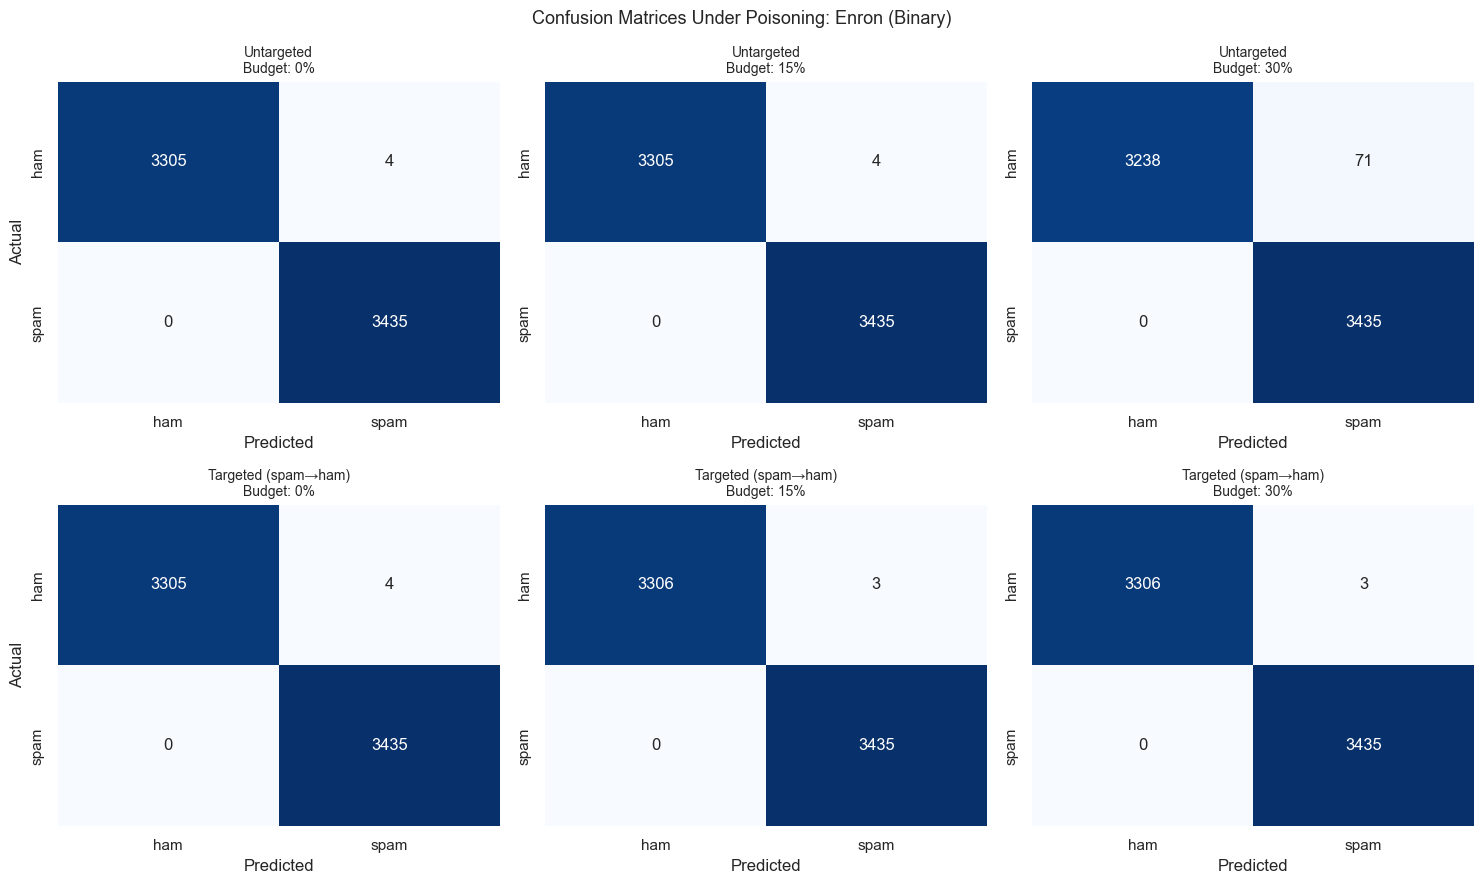

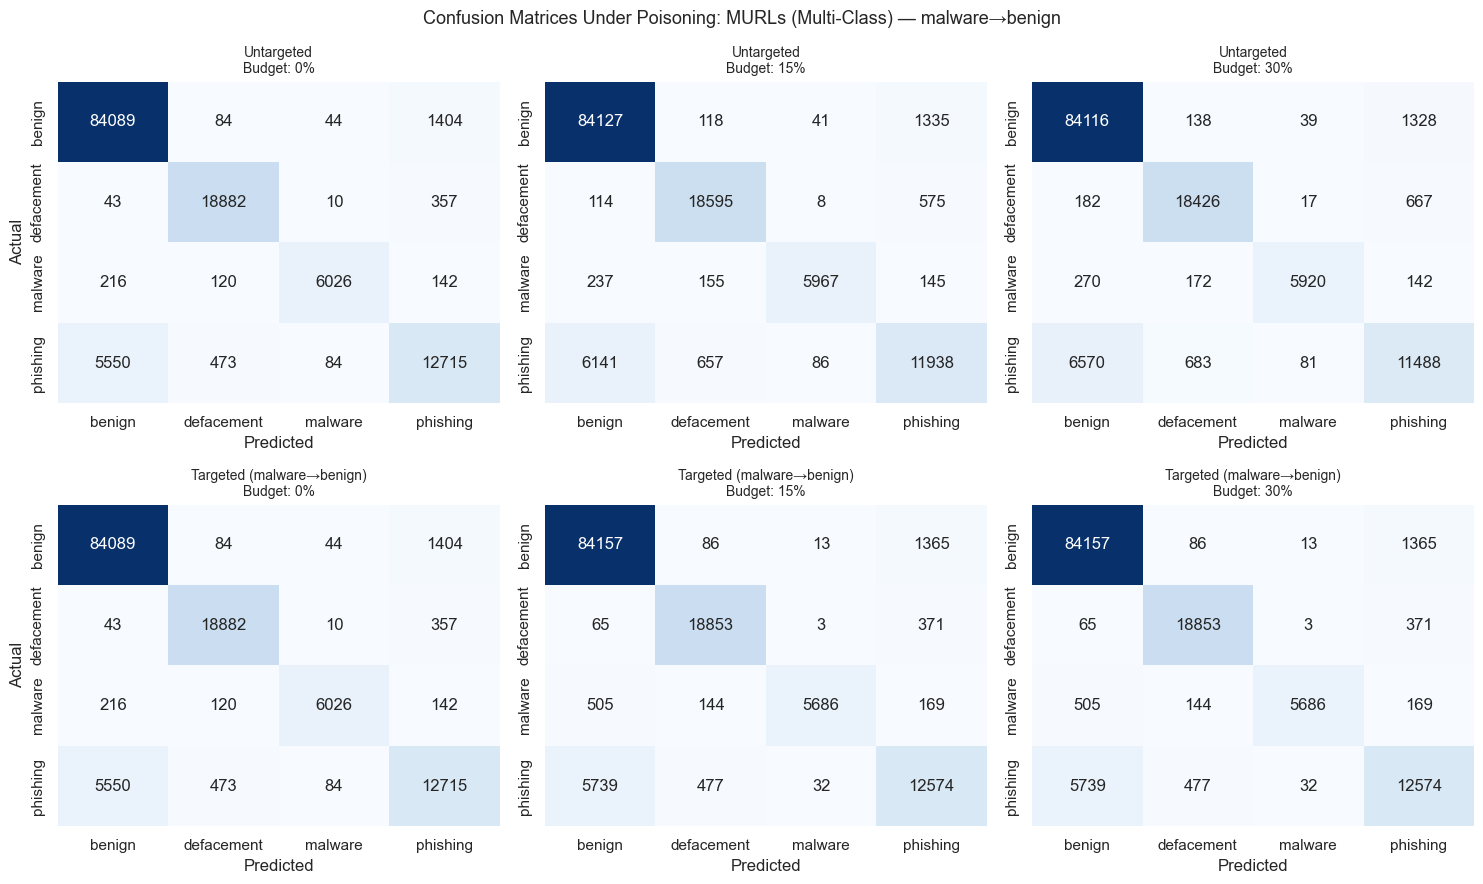

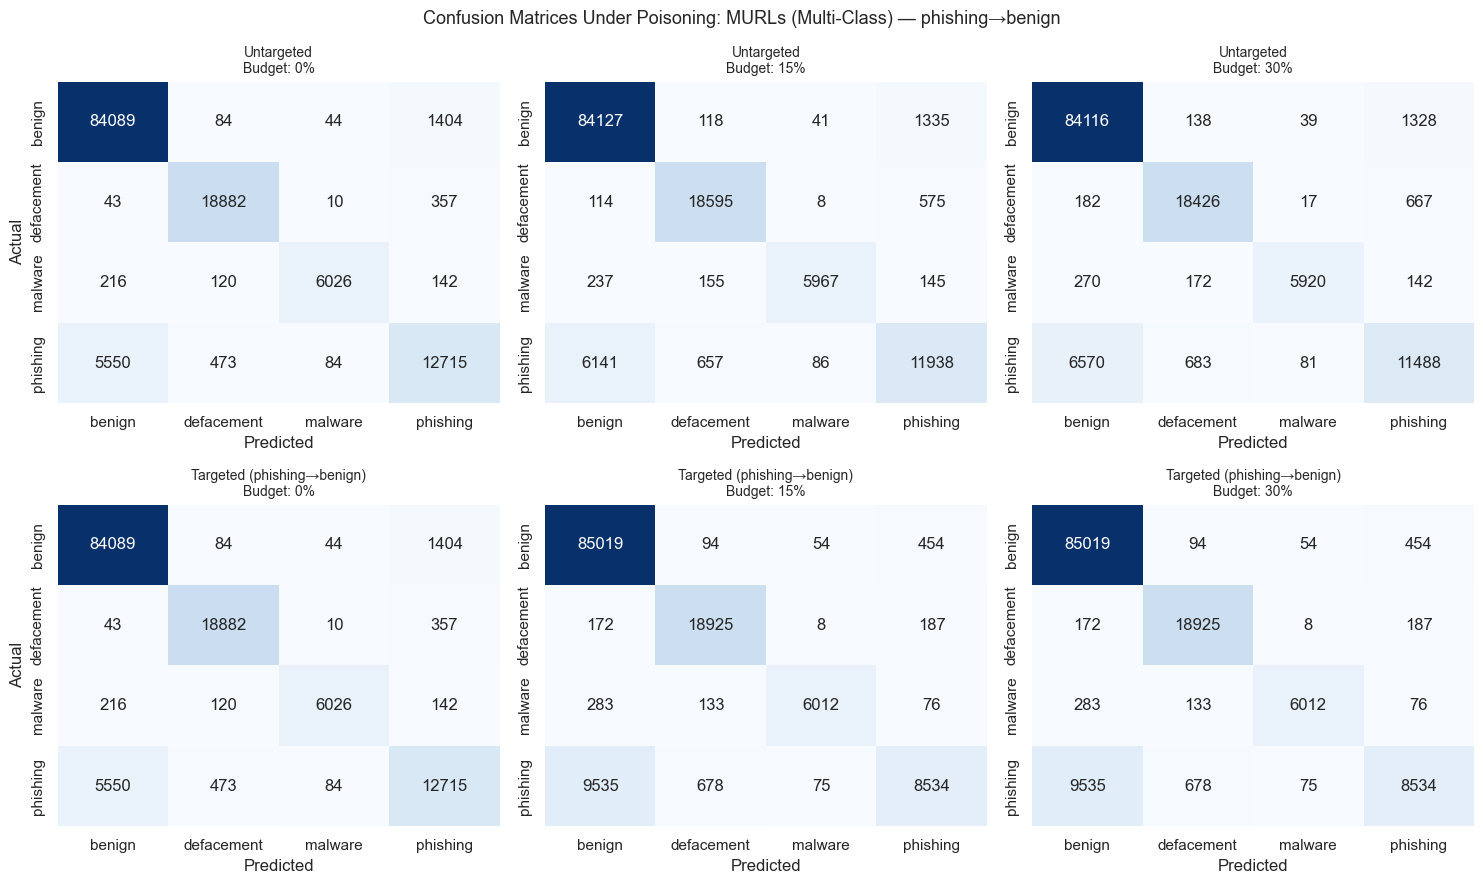

In [24]:
def plot_confusion_matrices(
    X_train,
    X_test,
    y_train: np.ndarray,
    y_test: np.ndarray,
    le: LabelEncoder,
    source_label: str,
    target_label: str,
    dataset_name: str,
    metric_average: str = "binary",
    budgets_to_show: list = [0.0, 0.15, 0.30],
    save_path=None,
) -> None:
    """
    Side-by-side confusion matrices at selected budgets for both
    untargeted and targeted attacks, showing how class confusion evolves.
    """
    source_class = le.transform([source_label])[0]
    target_class = le.transform([target_label])[0]
    class_names = le.classes_

    n_budgets = len(budgets_to_show)
    fig, axes = plt.subplots(
        2, n_budgets,
        figsize=(5 * n_budgets, 9),
    )
    fig.suptitle(f"Confusion Matrices Under Poisoning: {dataset_name}", fontsize=13)

    row_labels = ["Untargeted", f"Targeted ({source_label}→{target_label})"]

    for row, attack_type in enumerate(["untargeted", "targeted"]):
        for col, budget in enumerate(budgets_to_show):
            ax = axes[row, col]

            # Apply the right poisoning strategy
            if attack_type == "untargeted":
                y_poisoned = apply_label_flipping(
                    y_train,
                    budget=budget,
                    num_classes=len(class_names),
                    random_state=RANDOM_STATE,
                )
            else:
                y_poisoned = apply_targeted_poison(
                    y_train,
                    budget=budget,
                    source_class=source_class,
                    target_class=target_class,
                    random_state=RANDOM_STATE,
                )

            clf = build_classifier()
            clf.fit(X_train, y_poisoned)
            y_pred = clf.predict(X_test)

            cm = confusion_matrix(y_test, y_pred, labels=le.transform(class_names))
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax,
                cbar=False,
            )
            ax.set_title(f"{row_labels[row]}\nBudget: {int(budget * 100)}%", fontsize=10)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual" if col == 0 else "")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Enron confusion matrices
plot_confusion_matrices(
    X_train_e, X_test_e, y_train_e, y_test_e,
    le=le_e,
    source_label="spam",
    target_label="ham",
    dataset_name="Enron (Binary)",
    metric_average="binary",
    budgets_to_show=[0.0, 0.15, 0.30],
    save_path=Path("enron_confusion_matrices.png"),
)

# MURLs confusion matrices — malware→benign
plot_confusion_matrices(
    X_train_u, X_test_u, y_train_u, y_test_u,
    le=le_u,
    source_label="malware",
    target_label="benign",
    dataset_name="MURLs (Multi-Class) — malware→benign",
    metric_average="macro",
    budgets_to_show=[0.0, 0.15, 0.30],
    save_path=Path("MURLs_confusion_malware.png"),
)

# MURLs confusion matrices — phishing→benign
plot_confusion_matrices(
    X_train_u, X_test_u, y_train_u, y_test_u,
    le=le_u,
    source_label="phishing",
    target_label="benign",
    dataset_name="MURLs (Multi-Class) — phishing→benign",
    metric_average="macro",
    budgets_to_show=[0.0, 0.15, 0.30],
    save_path=Path("MURLs_confusion_phishing.png"),
)

## updated plots

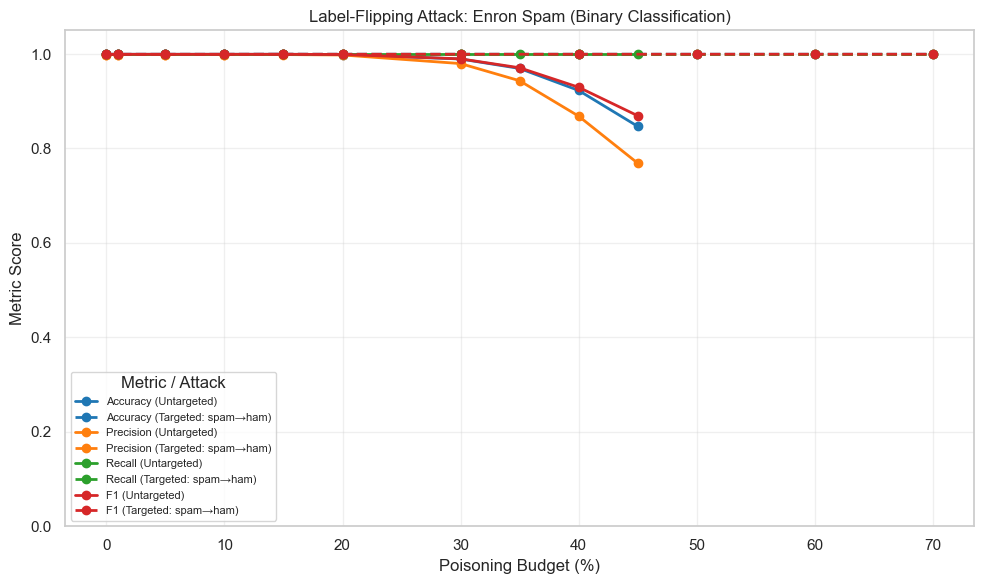

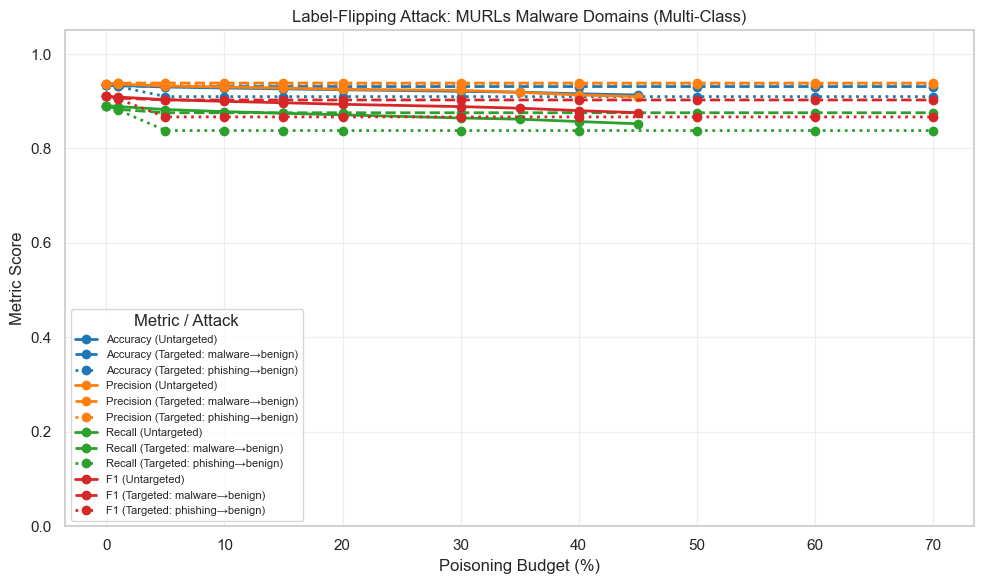

In [19]:
# ── Plots ─────────────────────────────────────────────────────────────────────
def plot_poisoning_degradation(
    df: pd.DataFrame,
    title: str,
    save_path=None,
) -> None:
    """
    Line plot per metric, with solid lines for untargeted and dashed lines
    for each targeted flip variant, so all attack types are visible at once.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_order = ["accuracy", "precision", "recall", "f1"]
    palette = sns.color_palette("tab10", n_colors=len(metrics_order))

    # Line styles per attack type
    style_map = {
        "untargeted":      ("solid",  "Untargeted"),
        "spam→ham":        ("dashed", "Targeted: spam→ham"),
        "malware→benign":  ("dashed", "Targeted: malware→benign"),
        "phishing→benign": ("dotted", "Targeted: phishing→benign"),
    }

    for metric, color in zip(metrics_order, palette):
        metric_df = df[df["metric"] == metric]

        for flip_key, (linestyle, flip_label) in style_map.items():
            if flip_key == "untargeted":
                subset = metric_df[metric_df["attack"] == "untargeted"]
            else:
                subset = metric_df[
                    (metric_df["attack"] == "targeted") &
                    (metric_df["flip"] == flip_key)
                ]

            if subset.empty:
                continue

            subset = subset.sort_values("budget_pct")
            ax.plot(
                subset["budget_pct"],
                subset["score"],
                marker="o",
                linewidth=2,
                linestyle=linestyle,
                label=f"{metric.capitalize()} ({flip_label})",
                color=color,
            )

    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Metric Score")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Metric / Attack", loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ── Enron: one plot combining untargeted + targeted ───────────────────────────
plot_poisoning_degradation(
    results_all[results_all["dataset"] == "Enron (Binary)"],
    title="Label-Flipping Attack: Enron Spam (Binary Classification)",
    save_path=Path("enron_poisoning_budget.png"),
)

# ── MURLs: one plot combining untargeted + both targeted variants ─────────────
plot_poisoning_degradation(
    results_all[results_all["dataset"] == "MURLs (Multi-Class)"],
    title="Label-Flipping Attack: MURLs Malware Domains (Multi-Class)",
    save_path=Path("MURLs_poisoning_budget.png"),
)

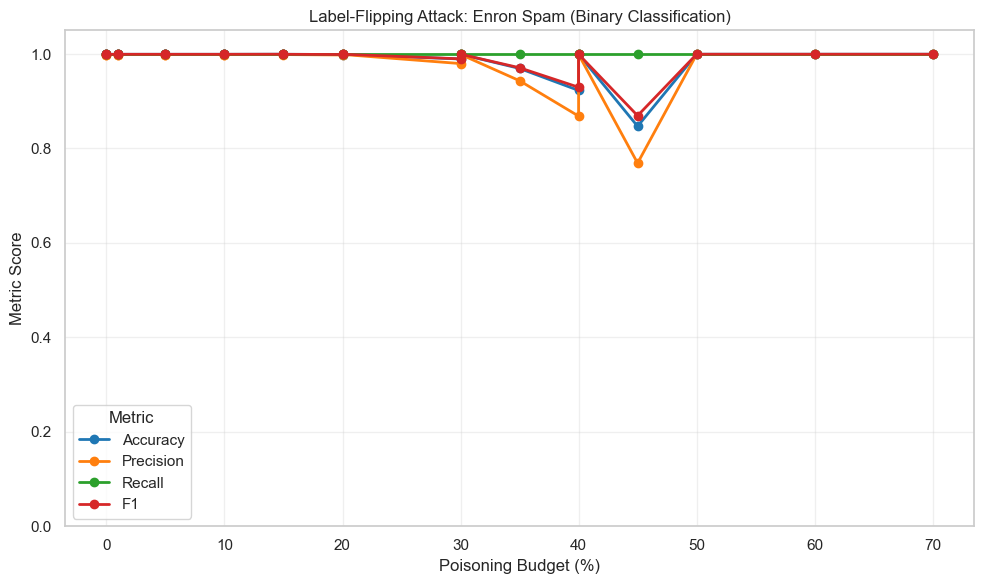

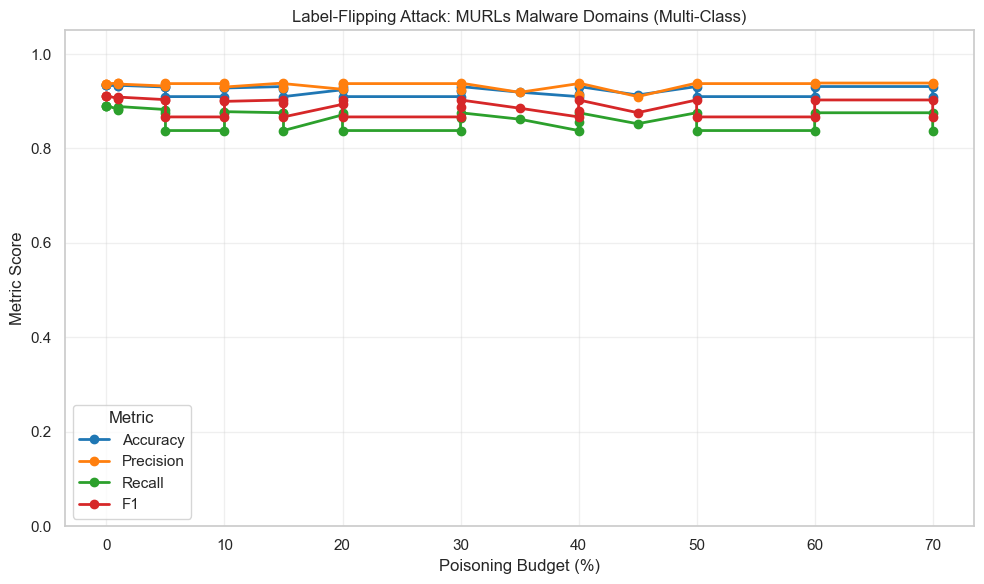

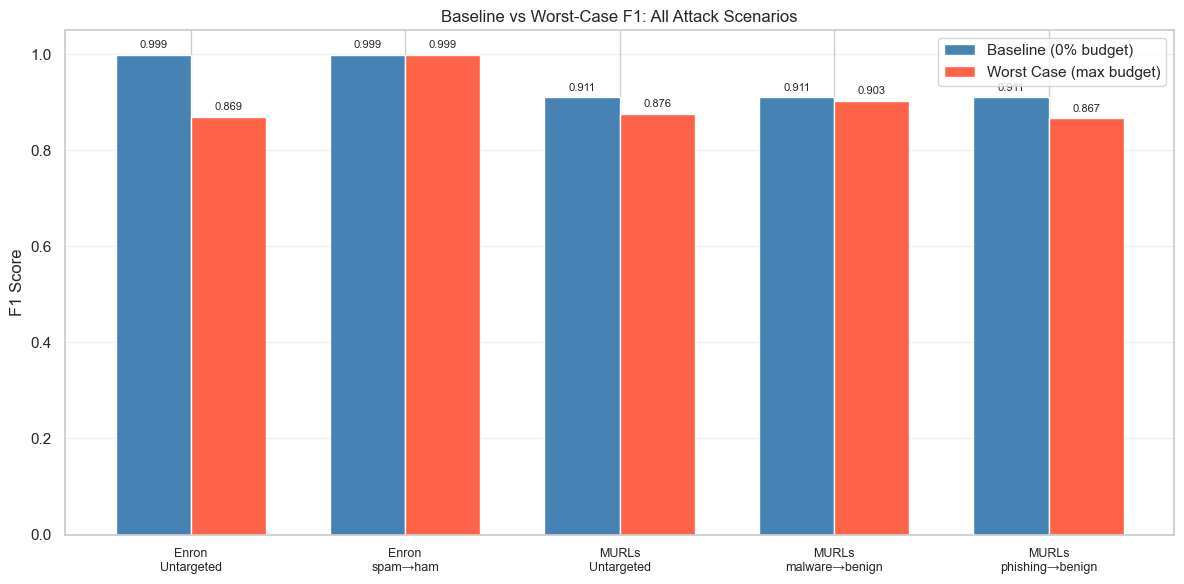

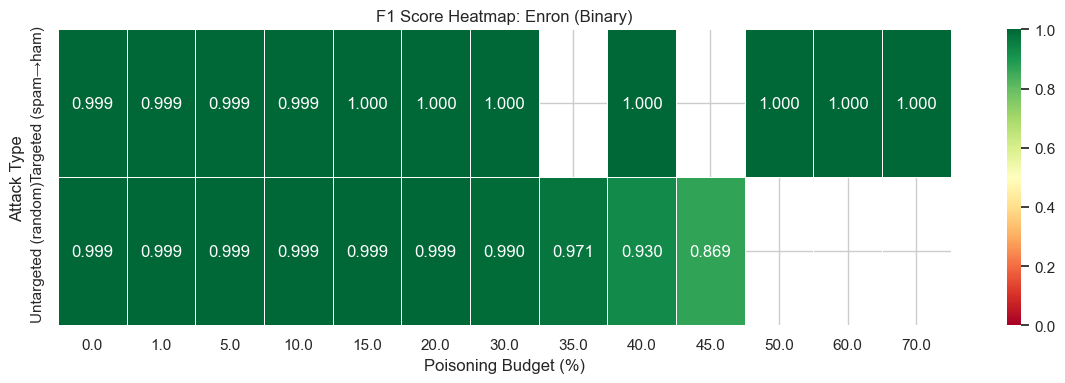

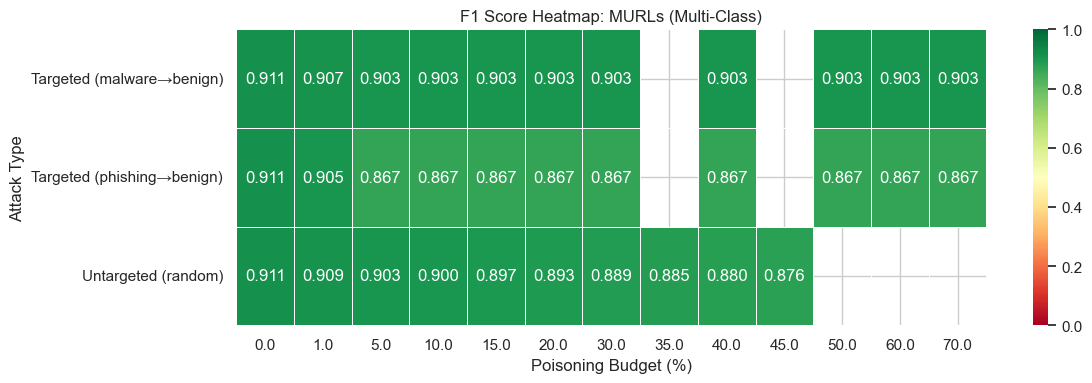

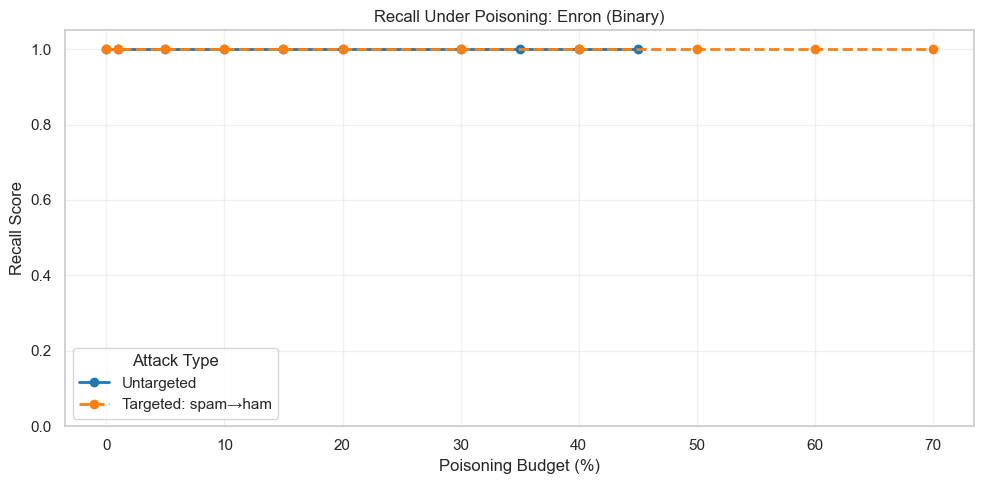

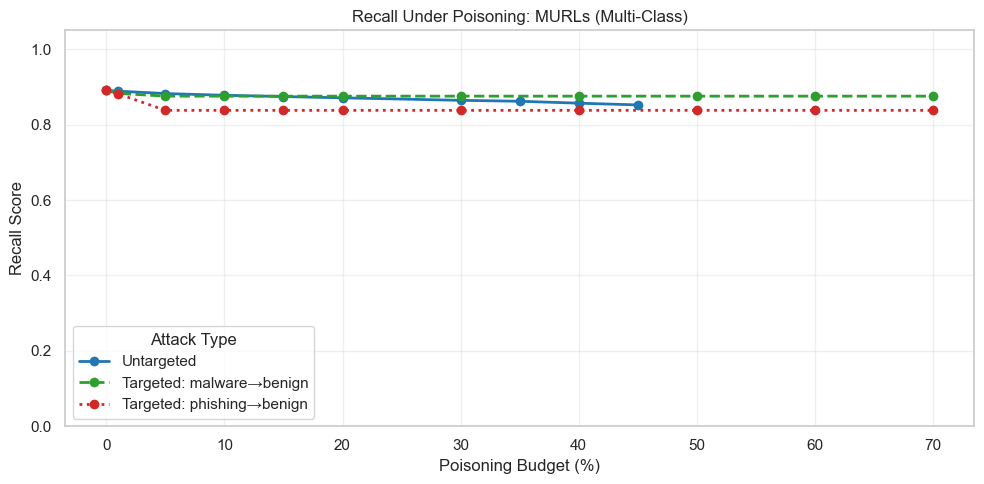

In [21]:
# ── Visual 2: Baseline vs Worst-Case Comparison Bar Chart ────────────────────
def plot_baseline_vs_poisoned(df: pd.DataFrame, save_path=None) -> None:
    """Bar chart comparing F1 at budget=0 vs worst case per attack type."""
    attack_configs = [
        ("Enron (Binary)",     "untargeted",  "random",          "Enron\nUntargeted"),
        ("Enron (Binary)",     "targeted",    "spam→ham",        "Enron\nspam→ham"),
        ("MURLs (Multi-Class)","untargeted",  "random",          "MURLs\nUntargeted"),
        ("MURLs (Multi-Class)","targeted",    "malware→benign",  "MURLs\nmalware→benign"),
        ("MURLs (Multi-Class)","targeted",    "phishing→benign", "MURLs\nphishing→benign"),
    ]

    baselines, worst_cases, labels = [], [], []
    for dataset, attack, flip, label in attack_configs:
        subset = df[
            (df["dataset"] == dataset) &
            (df["attack"] == attack) &
            (df["flip"] == flip) &
            (df["metric"] == "f1")
        ].sort_values("budget_pct")
        if subset.empty:
            continue
        baselines.append(subset[subset["budget_pct"] == 0]["score"].values[0])
        worst_cases.append(subset["score"].min())
        labels.append(label)

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, baselines,  width, label="Baseline (0% budget)", color="steelblue")
    bars2 = ax.bar(x + width/2, worst_cases, width, label="Worst Case (max budget)", color="tomato")

    ax.set_ylabel("F1 Score")
    ax.set_title("Baseline vs Worst-Case F1: All Attack Scenarios")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    # Annotate bars with values
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ── Visual 3: Heatmap of F1 Scores ───────────────────────────────────────────
def plot_f1_heatmap(df: pd.DataFrame, dataset_name: str, save_path=None) -> None:
    """Heatmap: budget % vs attack type, colored by F1 score."""
    subset = df[(df["dataset"] == dataset_name) & (df["metric"] == "f1")].copy()
    subset["attack_label"] = subset["flip"].apply(
        lambda x: "Untargeted (random)" if x == "random" else f"Targeted ({x})"
    )
    pivot = subset.pivot_table(
        index="attack_label", columns="budget_pct", values="score"
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0, vmax=1, ax=ax, linewidths=0.5
    )
    ax.set_title(f"F1 Score Heatmap: {dataset_name}")
    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Attack Type")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ── Visual 4: Recall Focus Plot ───────────────────────────────────────────────
def plot_recall_comparison(df: pd.DataFrame, dataset_name: str, save_path=None) -> None:
    """Recall-only plot comparing untargeted vs targeted attacks."""
    subset = df[
        (df["dataset"] == dataset_name) &
        (df["metric"] == "recall")
    ]
    style_map = {
        "random":          ("solid",  "Untargeted"),
        "spam→ham":        ("dashed", "Targeted: spam→ham"),
        "malware→benign":  ("dashed", "Targeted: malware→benign"),
        "phishing→benign": ("dotted", "Targeted: phishing→benign"),
    }
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = sns.color_palette("tab10", n_colors=len(style_map))
    for (flip_key, (linestyle, flip_label)), color in zip(style_map.items(), palette):
        s = subset[subset["flip"] == flip_key].sort_values("budget_pct")
        if s.empty:
            continue
        ax.plot(s["budget_pct"], s["score"], marker="o", linewidth=2,
                linestyle=linestyle, label=flip_label, color=color)

    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Recall Score")
    ax.set_title(f"Recall Under Poisoning: {dataset_name}")
    ax.set_ylim(0, 1.05)
    ax.legend(title="Attack Type")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ── Call all visualizations ───────────────────────────────────────────────────
# Visual 1 — already have this, just re-call with updated results_all
plot_poisoning_degradation(
    results_all[results_all["dataset"] == "Enron (Binary)"],
    title="Label-Flipping Attack: Enron Spam (Binary Classification)",
    save_path=Path("enron_poisoning_budget.png"),
)
plot_poisoning_degradation(
    results_all[results_all["dataset"] == "MURLs (Multi-Class)"],
    title="Label-Flipping Attack: MURLs Malware Domains (Multi-Class)",
    save_path=Path("MURLs_poisoning_budget.png"),
)

# Visual 2 — Baseline vs worst case
plot_baseline_vs_poisoned(
    results_all,
    save_path=Path("baseline_vs_poisoned.png"),
)

# Visual 3 — Heatmaps
plot_f1_heatmap(
    results_all,
    dataset_name="Enron (Binary)",
    save_path=Path("enron_f1_heatmap.png"),
)
plot_f1_heatmap(
    results_all,
    dataset_name="MURLs (Multi-Class)",
    save_path=Path("MURLs_f1_heatmap.png"),
)

# Visual 4 — Recall focus
plot_recall_comparison(
    results_all,
    dataset_name="Enron (Binary)",
    save_path=Path("enron_recall_comparison.png"),
)
plot_recall_comparison(
    results_all,
    dataset_name="MURLs (Multi-Class)",
    save_path=Path("MURLs_recall_comparison.png"),
)

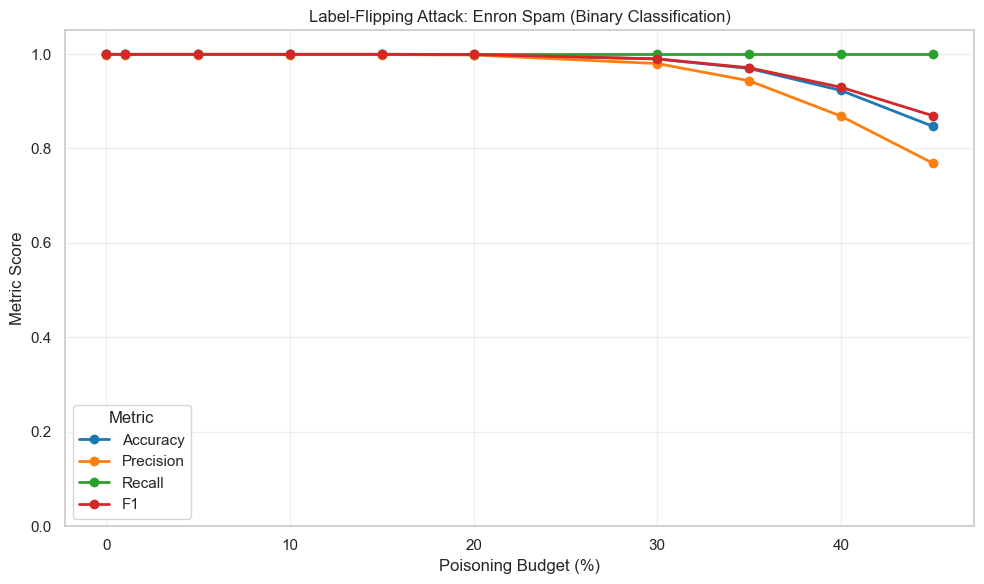

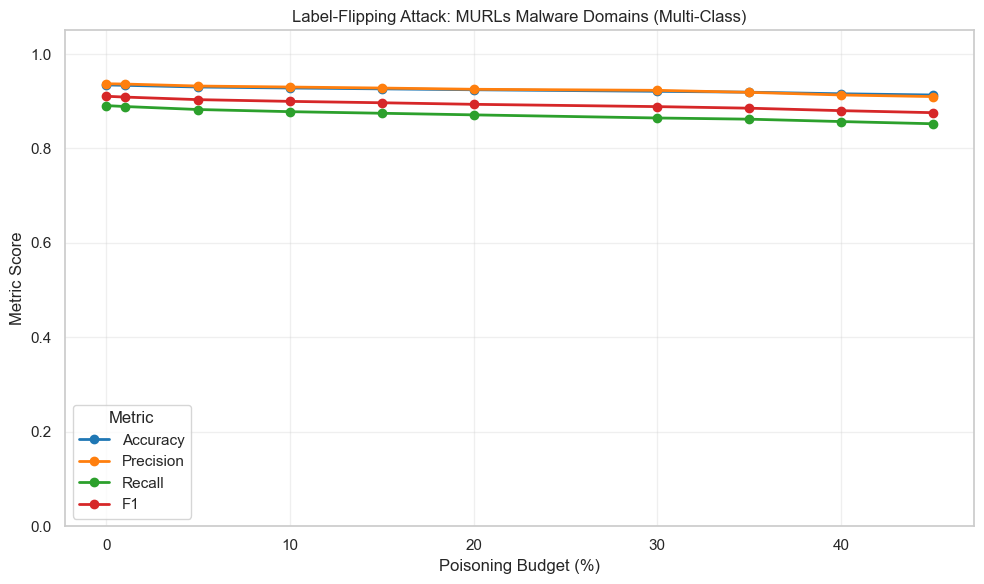

In [20]:
def plot_poisoning_degradation(
    df: pd.DataFrame,
    title: str,
    save_path=None,
) -> None:
    """Line plot: Poisoning Budget (%) vs metric scores."""
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_order = ["accuracy", "precision", "recall", "f1"]
    palette = sns.color_palette("tab10", n_colors=len(metrics_order))

    for metric, color in zip(metrics_order, palette):
        subset = df[df["metric"] == metric].sort_values("budget_pct")
        ax.plot(
            subset["budget_pct"],
            subset["score"],
            marker="o",
            linewidth=2,
            label=metric.capitalize(),
            color=color,
        )

    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Metric Score")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Metric", loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_poisoning_degradation(
    results_enron,
    title="Label-Flipping Attack: Enron Spam (Binary Classification)",
    save_path=Path("enron_poisoning_budget.png"),
)

plot_poisoning_degradation(
    results_MURLs,
    title="Label-Flipping Attack: MURLs Malware Domains (Multi-Class)",
    save_path=Path("MURLs_poisoning_budget.png"),
)